# Stage 08 — retraining policies

Eight retraining policies run through a day-by-day simulator (`src/retrain.py`)
that enforces the 21-day label delay: a trigger can only see losses whose h=21
label has matured. Policies: `no_retrain`, `periodic_{21,63,252}`, `adwin_raw`,
`adwin_directional`, `psi_budget_matched`, and the lookahead reference
`oracle_single_retrain`. All comparisons use QLIKE (Patton 2011).

Result: on the full 2823-day stream `adwin_directional` edges out `no_retrain`
by 7.6e-5 QLIKE, but that margin comes from 51 days outside the 11 validated
folds; within the fold-covered 2772 days no policy beats `no_retrain` (see the
note after the summary table). Outputs: `retrain_policies.csv`,
`retrain_summary.csv`, `drift_vs_gain.png`.


In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Environment bootstrap: Colab (mount Drive) or a local checkout.
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
    os.chdir("/content/drive/MyDrive/volatility-forecast")
except ModuleNotFoundError:
    p = os.path.abspath(os.getcwd())          # find the repo root locally
    while not os.path.isdir(os.path.join(p, "src")):
        parent = os.path.dirname(p)
        if parent == p:
            raise FileNotFoundError("repo root with src/ not found")
        p = parent
    os.chdir(p)

for m in list(sys.modules):   # notebooks cache imports; drop stale src modules
    if m.startswith('src'):
        del sys.modules[m]

from src.retrain import (FEATURES, TARGET, LABEL_DELAY,
                         fit_har_frame, simulate_retrain, AdwinStream)
from src.metrics import qlike
from src.drift import psi


In [2]:
df = pd.read_csv('data/processed/dataset.csv', index_col=0, parse_dates=True)
df = df.iloc[21:-21]          # drop 21-row rolling warmup head + 21-row forward-target tail
df.index.name = 'date'
assert len(df) == 3831, f"expected 3831, got {len(df)}"   # must match the 03-07 work frame
print(df.shape)


(3831, 21)


In [ ]:
# --- check 1: fit_har_frame reproduces the recorded OLS beta on the
#     first 1008 rows. (The engine's own initial model is fit on rows
#     0:987 -- start minus the 21-day label delay -- which matches the
#     embargo-adjusted static HAR of stages 06/07.) ---
beta0 = fit_har_frame(df.iloc[:1008])
print('initial beta :', np.round(beta0, 4))
print('expected     : [0.0048 0.0258 0.201  0.2949]   (recorded value, rows 0:1008)')

# --- check 2: no-retrain baseline = engine with a trigger that never fires ---
never_fire = lambda i, loss_history, visible_indices, df: False
no_retrain_log = simulate_retrain(df, never_fire, train_window=1008, start=1008)
print('\nno_retrain: rows =', len(no_retrain_log),
      '| n_retrains =', int(no_retrain_log['n_retrains'].iloc[-1]),
      '| mean QLIKE =', round(no_retrain_log['loss'].mean(), 5))

# --- check 3: causality unit test -- the newest loss a trigger could see on
#     day i must be at least LABEL_DELAY days old ---
nv = no_retrain_log.attrs['newest_visible']
start = no_retrain_log.attrs['start']
viol = [(i, v) for i, v in zip(range(start, len(df)), nv) if v >= 0 and v > i - LABEL_DELAY]
assert not viol, f"look-ahead violation at {viol[:3]}"
print('causality OK : newest visible loss <= i - 21 for all',
      sum(v >= 0 for v in nv), 'days with a matured loss')

no_retrain_log.head()


In [4]:
# Periodic baselines: retrain every k days regardless of performance.
def make_periodic_trigger(k, start=1008):
    def trigger(i, loss_history, visible_indices, df):
        return i > start and (i - start) % k == 0
    return trigger

results = {'no_retrain': no_retrain_log}

for k in (21, 63, 252):
    results[f'periodic_{k}'] = simulate_retrain(df, make_periodic_trigger(k),
                                                train_window=1008, start=1008)

summary = pd.DataFrame({
    name: {'n_retrains': int(lg['n_retrains'].iloc[-1]),
           'mean_QLIKE': lg['loss'].mean(),
           'median_QLIKE': lg['loss'].median()}
    for name, lg in results.items()
}).T
print(summary.round(5))


              n_retrains  mean_QLIKE  median_QLIKE
no_retrain           0.0     0.07455       0.02702
periodic_21        134.0     0.07710       0.02967
periodic_63         44.0     0.07655       0.02806
periodic_252        11.0     0.07706       0.02845


In [5]:
# ADWIN trigger. The detector watches a binary stream: for each newly
# matured loss, 1 if the model's QLIKE was worse than persistence
# (forecast = trailing rv21) that day, else 0. Comparing against
# persistence removes the shared volatility level, so the stream tracks
# "is the model losing ground", not "did volatility go up".
def make_adwin_trigger(det, start=1008):
    state = {'n_consumed': 0, 'last_retrain': start}
    diagnostics = []

    def trigger(i, loss_history, visible_indices, df):
        triggered = False
        while state['n_consumed'] < len(visible_indices):
            k = state['n_consumed']
            s = visible_indices[k]
            state['n_consumed'] += 1
            if s < state['last_retrain']:
                continue   # judge each model version on its own record only
            loss_model = loss_history[k]
            # persistence loss for day s: its label has matured (s <= i - 21)
            loss_persistence = qlike(df[TARGET].iloc[s], df['rv21'].iloc[s])
            if det.update(1.0 if loss_model > loss_persistence else 0.0):
                mu0, mu1, n0, n1 = det.last_cut
                diagnostics.append({'i': i, 'date': df.index[i],
                                    'mu_old': mu0, 'mu_recent': mu1,
                                    'gap': mu1 - mu0, 'n0': n0, 'n1': n1,
                                    'direction': 'WORSE' if mu1 > mu0 else 'better'})
                triggered = True
        if triggered:
            det.reset()
            state['last_retrain'] = i
        return triggered

    return trigger, diagnostics


# adwin_raw: plain two-sided ADWIN -- fires on any mean change, either direction
trigger, diag_raw = make_adwin_trigger(AdwinStream(delta=0.002, min_n=30))
adwin_raw_log = simulate_retrain(df, trigger, train_window=1008, start=1008)
results['adwin_raw'] = adwin_raw_log
assert int(adwin_raw_log['n_retrains'].iloc[-1]) == 26   # reproducibility check

diag_raw_df = pd.DataFrame(diag_raw)
diag_raw_df['fold'] = (diag_raw_df['i'] - 1008) // 252
print(diag_raw_df.round({'mu_old': 3, 'mu_recent': 3, 'gap': 3})
      [['date', 'fold', 'mu_old', 'mu_recent', 'gap', 'direction']].to_string(index=False))
print('\nWORSE fires:', (diag_raw_df['direction'] == 'WORSE').sum(), '/', len(diag_raw_df))

# per-fold QLIKE: adwin_raw vs no_retrain
def fold_ids(lg):
    """Fold id per log row; folds are 252-day blocks starting at row 1008."""
    fid = ((lg['i'] - 1008) // 252).to_numpy().copy()
    fid[fid >= 11] = -1        # tail rows beyond fold 10
    return fid

per_fold = pd.DataFrame({'no_retrain': results['no_retrain']['loss'].groupby(fold_ids(adwin_raw_log)).mean(),
                         'adwin_raw': adwin_raw_log['loss'].groupby(fold_ids(adwin_raw_log)).mean()}).drop(index=-1)
per_fold['diff'] = per_fold['adwin_raw'] - per_fold['no_retrain']
print('\n', per_fold.round(4))


      date  fold  mu_old  mu_recent    gap direction
2016-02-16     1   0.344      1.000  0.656     WORSE
2016-05-13     1   0.000      1.000  1.000     WORSE
2016-08-10     1   1.000      0.061 -0.939    better
2016-10-20     1   0.000      1.000  1.000     WORSE
2017-01-26     1   0.212      1.000  0.788     WORSE
2017-05-25     2   1.000      0.000 -1.000    better
2017-10-25     2   0.171      1.000  0.829     WORSE
2018-02-12     3   0.905      0.083 -0.821    better
2018-05-17     3   0.781      0.000 -0.781    better
2018-09-19     3   0.170      0.842  0.672     WORSE
2018-12-10     3   0.000      0.800  0.800     WORSE
2019-02-22     4   1.000      0.050 -0.950    better
2019-12-16     4   0.188      0.688  0.499     WORSE
2020-03-25     5   0.132      1.000  0.868     WORSE
2020-07-01     5   0.025      1.000  0.975     WORSE
2021-08-12     6   0.408      1.000  0.592     WORSE
2021-10-22     6   0.909      0.000 -0.909    better
2022-03-22     7   0.097      0.654  0.557    

In [ ]:
# adwin_directional: one-sided minimum-evidence variant. Only fire when
# the RECENT mean is worse (one_sided), by at least 0.2 (gap_min), with
# at least 21 points in the recent window (n1_min). This screens out
# fires on improvements and on tiny or noisy gaps. Note that gap_min is
# redundant at delta=0.002: the Hoeffding cut already enforces a larger
# effect-size floor at the window sizes that occur here (see the
# sensitivity check in the last cell), so the effective repairs are
# one_sided and n1_min.
det = AdwinStream(delta=0.002, min_n=30, one_sided=True, gap_min=0.2, n1_min=21)
trigger, diag_directional = make_adwin_trigger(det)
adwin_directional_log = simulate_retrain(df, trigger, train_window=1008, start=1008)
results['adwin_directional'] = adwin_directional_log

diag_dir_df = pd.DataFrame(diag_directional)
if len(diag_dir_df):
    diag_dir_df['fold'] = (diag_dir_df['i'] - 1008) // 252
    print(diag_dir_df.round({'mu_old': 3, 'mu_recent': 3, 'gap': 3})
          [['date', 'fold', 'mu_old', 'mu_recent', 'gap', 'n0', 'n1']].to_string(index=False))
print('\nn_retrains :', int(adwin_directional_log['n_retrains'].iloc[-1]),
      '| mean QLIKE :', round(adwin_directional_log['loss'].mean(), 5))
# reference (this run, stream frame): no_retrain 0.074554 | adwin_raw 0.074650 |
#   periodic_63 0.076546 | oracle_single_retrain 0.073698

per_fold = pd.DataFrame({'no_retrain': results['no_retrain']['loss'].groupby(fold_ids(adwin_directional_log)).mean(),
                         'adwin_directional': adwin_directional_log['loss'].groupby(fold_ids(adwin_directional_log)).mean()}).drop(index=-1)
per_fold['diff'] = per_fold['adwin_directional'] - per_fold['no_retrain']
print('\n', per_fold.round(4))


In [ ]:
# oracle_single_retrain: retrain exactly once, at the first ADWIN
# detection inside f07 (2022-03-22 on the real data, from the adwin_raw
# diagnostics above). This uses hindsight -- we already know f07 is
# where the drift was -- so it is a lookahead-constructed reference
# line, not a deployable strategy and not a performance ceiling: other
# policies can and do beat it inside individual folds.
f07_detections = diag_raw_df[diag_raw_df['fold'] == 7]
assert len(f07_detections), "adwin_raw never fired in f07"
retrain_i = int(f07_detections['i'].iloc[0])
print('single retrain at i =', retrain_i, '=', df.index[retrain_i].date())

def oracle_trigger(i, loss_history, visible_indices, df, fire_at=retrain_i):
    return i == fire_at

oracle_log = simulate_retrain(df, oracle_trigger, train_window=1008, start=1008)
results['oracle_single_retrain'] = oracle_log

per_fold = pd.DataFrame({'no_retrain': results['no_retrain']['loss'].groupby(fold_ids(oracle_log)).mean(),
                         'oracle_single_retrain': oracle_log['loss'].groupby(fold_ids(oracle_log)).mean()}).drop(index=-1)
per_fold['diff'] = per_fold['oracle_single_retrain'] - per_fold['no_retrain']
print(per_fold.round(4))
print('\nmean QLIKE  oracle_single_retrain :', round(oracle_log['loss'].mean(), 5),
      '| no_retrain :', round(results['no_retrain']['loss'].mean(), 5))


**The f08 penalty is a transient post-retrain tax, not persistent
window-contamination.** The oracle's time profile above shows it directly: a
single retrain inside f07 gains −0.01732 at f07, costs **+0.01333** at f08, and
the differential is already back to −0.00086 at f09 and −0.00273 at f10. The
cost is concentrated in the one fold after the retrain and reverses sign within
a year.

Across policies the f08 loss has a two-tier structure:

- **0 fires at f08** (`oracle_single_retrain`, `psi_budget_matched`,
  `adwin_directional`): ≈ +0.0133 — entirely carry-over from the f07 retrain.
- **≥1 fire at f08** (`periodic_21/63/252`, `adwin_raw`): ≈ +0.0191 to +0.0205,
  i.e. an additional ≈ +0.006 in-fold level shift.

The additional cost is not proportional to fire count (1 fire at f08 costs
+0.0058 extra, 12 fires +0.0072), which points to a level shift on the first
in-fold retrain rather than accumulating damage. So the open problems are (1)
detecting drift entry early enough, and (2) a bounded one-fold post-retrain tax
— not an unsolvable training-window contamination.


In [ ]:
# PSI trigger: watches the FEATURE distribution P(X) instead of the loss.
# Features are observable the same day (no label needed), so this
# trigger has no 21-day delay -- its potential edge over loss triggers.
def make_psi_trigger(threshold=0.25, recent_win=63, spacing=21,
                     train_window=1008, start=1008, label_delay=21):
    state = {'ref_begin': 0, 'ref_end': start, 'last_retrain': -10**9}
    diagnostics = []

    def trigger(i, loss_history, visible_indices, df):
        if i - state['last_retrain'] < spacing:   # cooldown between fires
            return False
        if i - recent_win < 0:
            return False
        vals = {}
        for f in FEATURES:
            ref = df[f].iloc[state['ref_begin']:state['ref_end']].values
            recent = df[f].iloc[i - recent_win:i + 1].values   # features observable same day
            vals[f] = psi(ref, recent)
        worst = max(vals, key=vals.get)
        if vals[worst] > threshold:
            # move the reference to the window the engine is about to retrain on
            end = i - label_delay
            state['ref_begin'], state['ref_end'] = max(0, end - train_window), end
            state['last_retrain'] = i
            diagnostics.append({'i': i, 'date': df.index[i], 'worst_feat': worst,
                                **{f'psi_{f}': round(v, 3) for f, v in vals.items()}})
            return True
        return False

    return trigger, diagnostics


# standard textbook threshold: PSI > 0.25 = large shift
trigger, diag_psi = make_psi_trigger(threshold=0.25)
psi_log = simulate_retrain(df, trigger, train_window=1008, start=1008)
results['psi'] = psi_log

diag_psi_df = pd.DataFrame(diag_psi)
if len(diag_psi_df):
    diag_psi_df['fold'] = (diag_psi_df['i'] - 1008) // 252
    print(diag_psi_df[['date', 'fold', 'worst_feat', 'psi_rv1', 'psi_rv5', 'psi_rv21']]
          .to_string(index=False))
print('\nn_retrains :', int(psi_log['n_retrains'].iloc[-1]),
      '| mean QLIKE :', round(psi_log['loss'].mean(), 5))
# reference (this run, stream frame): no_retrain 0.074554 | adwin_raw 0.074650 |
#   adwin_directional 0.074478 | periodic_63 0.076546 | oracle_single_retrain 0.073698

per_fold = pd.DataFrame({'no_retrain': results['no_retrain']['loss'].groupby(fold_ids(psi_log)).mean(),
                         'adwin_directional': results['adwin_directional']['loss'].groupby(fold_ids(psi_log)).mean(),
                         'psi': psi_log['loss'].groupby(fold_ids(psi_log)).mean()}).drop(index=-1)
per_fold['psi_minus_no_retrain'] = per_fold['psi'] - per_fold['no_retrain']
print('\n', per_fold.round(4))


In [9]:
# psi_budget_matched: threshold raised (tuned after the fact) until the
# PSI trigger fires about as often as adwin_directional, so the two can
# be compared at the same retrain budget. Diagnostic only -- picking the
# threshold this way uses full-sample knowledge.
trigger, diag_psi_matched = make_psi_trigger(threshold=10.7, recent_win=63, spacing=21)
psi_budget_matched_log = simulate_retrain(df, trigger, train_window=1008, start=1008)
results['psi_budget_matched'] = psi_budget_matched_log

diag_psi_matched_df = pd.DataFrame(diag_psi_matched)
if len(diag_psi_matched_df):
    diag_psi_matched_df['fold'] = (diag_psi_matched_df['i'] - 1008) // 252
    print(diag_psi_matched_df[['date', 'fold', 'worst_feat', 'psi_rv1', 'psi_rv5', 'psi_rv21']]
          .to_string(index=False))
print('\nn_retrains :', int(psi_budget_matched_log['n_retrains'].iloc[-1]),
      '| mean QLIKE :', round(psi_budget_matched_log['loss'].mean(), 5))

per_fold = pd.DataFrame({'no_retrain': results['no_retrain']['loss'].groupby(fold_ids(psi_budget_matched_log)).mean(),
                         'adwin_directional': results['adwin_directional']['loss'].groupby(fold_ids(psi_budget_matched_log)).mean(),
                         'psi_budget_matched': psi_budget_matched_log['loss'].groupby(fold_ids(psi_budget_matched_log)).mean()}).drop(index=-1)
per_fold['psi_minus_no_retrain'] = per_fold['psi_budget_matched'] - per_fold['no_retrain']
print('\n', per_fold.round(4))


      date  fold worst_feat  psi_rv1  psi_rv5  psi_rv21
2017-04-04     2       rv21    1.608    6.531    11.095
2017-05-04     2       rv21    1.509    5.406    12.429
2019-01-11     3       rv21    0.979    9.165    11.256
2020-05-22     5       rv21    2.346    9.562    10.981
2022-05-05     7       rv21    2.380   10.496    10.723

n_retrains : 5 | mean QLIKE : 0.07618

     no_retrain  adwin_directional  psi_budget_matched  psi_minus_no_retrain
0       0.0643             0.0643              0.0643                0.0000
1       0.0797             0.0730              0.0797                0.0000
2       0.0716             0.0785              0.0698               -0.0018
3       0.0835             0.0951              0.1079                0.0244
4       0.0740             0.0712              0.0750                0.0010
5       0.1905             0.1928              0.1890               -0.0015
6       0.0589             0.0579              0.0627                0.0039
7       0.0607 

In [10]:
POLICIES = ['no_retrain', 'periodic_21', 'periodic_63', 'periodic_252',
            'adwin_raw', 'adwin_directional', 'psi_budget_matched',
            'oracle_single_retrain']

summary = pd.DataFrame({
    name: {'n_retrains': int(lg['n_retrains'].iloc[-1]),
           'mean_QLIKE': lg['loss'].mean(),
           'mean_MSE': ((lg['y_true'] - lg['y_pred'])**2).mean()}
    for name, lg in results.items() if name in POLICIES
}).T.sort_values('mean_QLIKE')
summary['rank_QLIKE'] = summary['mean_QLIKE'].rank().astype(int)
summary['rank_MSE'] = summary['mean_MSE'].rank().astype(int)
print(summary.round(6))

# where did each policy retrain? (policy x fold count matrix)
def fold_of(i):
    f = (i - 1008) // 252
    return f if f < 11 else -1

retrain_counts = {}
for name in POLICIES:
    lg = results[name]
    fires = lg.loc[lg['retrain_triggered'], 'i'].map(fold_of)
    retrain_counts[name] = fires.value_counts().reindex(range(11), fill_value=0)
retrain_matrix = pd.DataFrame(retrain_counts).T
retrain_matrix.columns = [f'f{c:02d}' for c in retrain_matrix.columns]
print('\nretrain-location matrix (rows=policy, cols=fold):')
print(retrain_matrix)


                       n_retrains  mean_QLIKE  mean_MSE  rank_QLIKE  rank_MSE
oracle_single_retrain         1.0    0.073698  0.000030           1         1
adwin_directional            12.0    0.074478  0.000031           2         3
no_retrain                    0.0    0.074554  0.000031           3         2
adwin_raw                    26.0    0.074650  0.000031           4         4
psi_budget_matched            5.0    0.076179  0.000031           5         5
periodic_63                  44.0    0.076546  0.000032           6         6
periodic_252                 11.0    0.077058  0.000032           7         7
periodic_21                 134.0    0.077097  0.000032           8         8

retrain-location matrix (rows=policy, cols=fold):
                       f00  f01  f02  f03  f04  f05  f06  f07  f08  f09  f10
no_retrain               0    0    0    0    0    0    0    0    0    0    0
periodic_21             11   12   12   12   12   12   12   12   12   12   12
periodic_63     

**Frame sensitivity — read the ranking above with care.** The summary table is
computed on the full 2823-day stream. The 11 folds cover 2772 of those days; the
remaining 51 days fall between fold boundaries and after f10. Those 51 days are
easy days for every retraining policy (QLIKE 0.0157–0.0171 vs 0.0256 for
`no_retrain`), so including them shifts every policy's margin against
`no_retrain` by roughly −1.6e-4 to −2.1e-4 — near-uniformly, not in a way
specific to any trigger. `adwin_directional` is the only policy whose
within-fold deficit (+1.04e-4) is smaller than that offset, so it is the only
one whose sign flips between frames: −7.56e-5 on the stream, +1.04e-4 on the
fold-covered rows. **Within the validated fold structure, no policy beats
`no_retrain`.** Headline numbers therefore always cite the stream frame, and
per-fold analysis the fold frame, never a mixture.


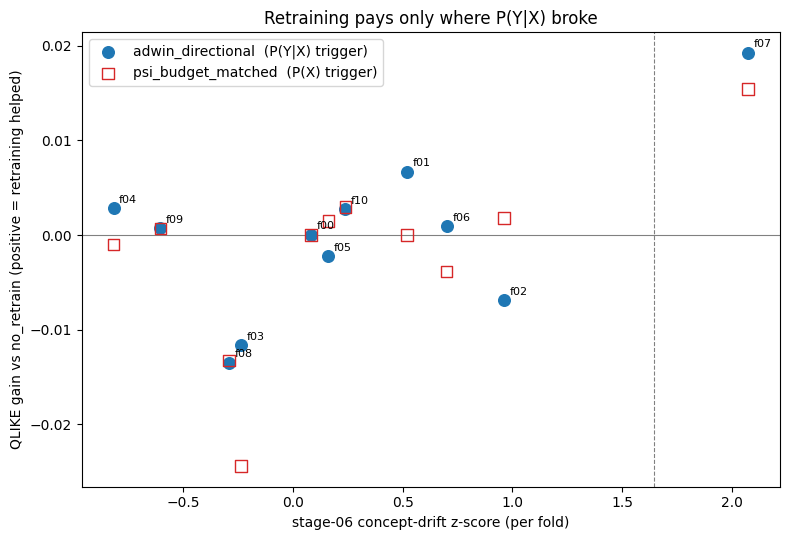

saved: drift_vs_gain.png / retrain_policies.csv / retrain_summary.csv
retrain_policies.csv shape: (2823, 40)


In [11]:
# Drift-vs-gain plot: x = stage-06 concept-drift z-score per fold,
# y = QLIKE improvement over no_retrain. If retraining only pays where
# P(Y|X) actually broke, the points should rise with z.
drift06 = pd.read_csv('data/processed/concept_drift.csv')
drift_z = dict(zip(drift06['fold'], drift06['z']))

def per_fold_gain(name):
    lg = results[name]
    pol = lg['loss'].groupby(fold_ids(lg)).mean().drop(index=-1)
    base = results['no_retrain']['loss'].groupby(fold_ids(results['no_retrain'])).mean().drop(index=-1)
    return base - pol            # positive = retraining helped

gain_adwin = per_fold_gain('adwin_directional')
gain_psi = per_fold_gain('psi_budget_matched')
z = pd.Series(drift_z)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(1.645, color='gray', lw=0.8, ls='--')
ax.scatter(z, gain_adwin, s=70, label='adwin_directional  (P(Y|X) trigger)', zorder=3)
ax.scatter(z, gain_psi, s=70, marker='s', facecolors='none',
           edgecolors='tab:red', label='psi_budget_matched  (P(X) trigger)', zorder=3)
for f in range(11):
    ax.annotate(f'f{f:02d}', (z[f], gain_adwin[f]), fontsize=8,
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('stage-06 concept-drift z-score (per fold)')
ax.set_ylabel('QLIKE gain vs no_retrain (positive = retraining helped)')
ax.set_title('Retraining pays only where P(Y|X) broke')
ax.legend()
fig.tight_layout()
fig.savefig('data/processed/drift_vs_gain.png', dpi=150)
plt.show()

# exports for later stages
daily = pd.concat({n: results[n][['y_pred', 'y_true', 'loss', 'retrain_triggered', 'n_retrains']]
                   for n in POLICIES}, axis=1)
daily.to_csv('data/processed/retrain_policies.csv')
summary.to_csv('data/processed/retrain_summary.csv')
print('saved: drift_vs_gain.png / retrain_policies.csv / retrain_summary.csv')
print('retrain_policies.csv shape:', daily.shape)


In [ ]:
# Sensitivity of adwin_directional to its two extra knobs, at the
# deployed configuration delta=0.002. The output shows n1_min drives
# everything and gap_min changes nothing over 0.1-0.3: the Hoeffding
# cut already imposes a larger effect-size floor at the sub-window
# sizes that occur (n1 = 21-34), so gap_min is a redundant constraint.
# This is a spot check at one delta, not a hyperparameter sweep.
rows = []
for gap in (0.1, 0.2, 0.3):
    for n1 in (21, 42):
        det = AdwinStream(delta=0.002, min_n=30, one_sided=True, gap_min=gap, n1_min=n1)
        trigger, diag = make_adwin_trigger(det)
        lg = simulate_retrain(df, trigger, train_window=1008, start=1008)
        dd = pd.DataFrame(diag)
        f07_fires = dd[(dd['i'] - 1008) // 252 == 7] if len(dd) else dd
        f08_fires = dd[(dd['i'] - 1008) // 252 == 8] if len(dd) else dd
        rows.append({'gap_min': gap, 'n1_min': n1,
                     'n_retrains': int(lg['n_retrains'].iloc[-1]),
                     'mean_QLIKE': round(lg['loss'].mean(), 5),
                     'f07_first': str(f07_fires['date'].iloc[0].date()) if len(f07_fires) else 'NONE',
                     'f08_fires': len(f08_fires)})
sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False))
# reference (this run, stream frame): no_retrain 0.074554 |
#   adwin_directional(0.2, 21) 0.074478 | oracle_single_retrain 0.073698
